# 第32篇｜随机变量与常见概率分布

> 这是「数据分析从入门到精通」系列的第 32 篇。条件概率和贝叶斯讲完了，这篇来聊随机变量和常见概率分布。二项分布、泊松分布、正态分布……这些名字你一定见过，这篇让你彻底搞清楚它们是什么、什么时候用。

---

嗨，我是小荷～

上一篇讲了贝叶斯定理，知道了怎么更新概率估计。今天讲**常见概率分布**——这是你在数据分析、机器学习里会反复遇到的基础知识。

为什么要知道分布？因为不同的随机现象，遵循不同的分布规律。用对了分布，你的建模就更接近现实。

---

## 一、随机变量是什么？

**随机变量**是用数值表示随机试验结果的变量。

- 投一枚硬币：正面=1，反面=0 → 离散随机变量
- 测量一个人的体重 → 连续随机变量

---

## 二、二项分布（Binomial Distribution）

**适用场景**：n 次独立试验，每次成功概率为 p，成功次数 X 服从 B(n, p)。

**现实例子**：
- 发 100 封推广邮件，每封点击率 5%，点击次数是多少？
- 抽样 500 件产品，合格率 98%，不合格品数量分布？


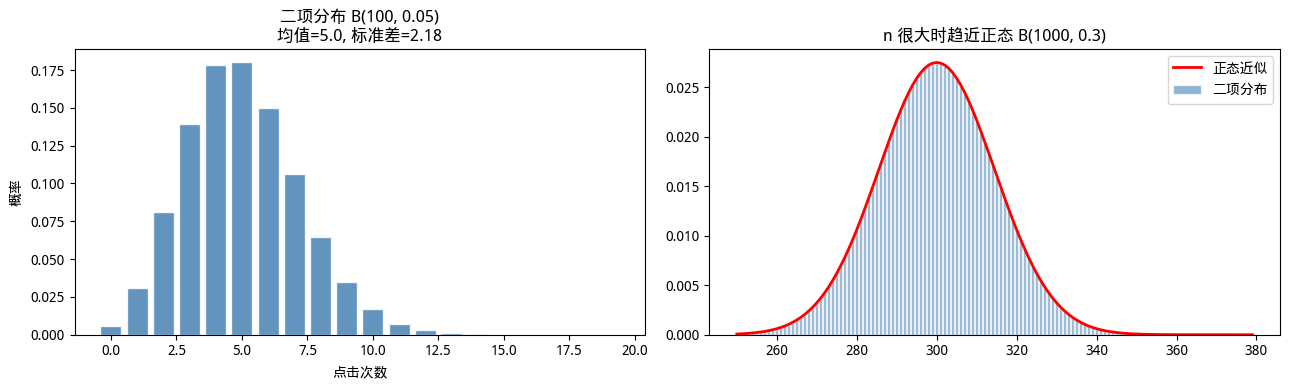

发100封邮件，至少8人点击的概率：0.1280 (12.80%)


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

# 发 100 封邮件，每封点击率 5%
n, p = 100, 0.05
x = np.arange(0, 20)
pmf = stats.binom.pmf(x, n, p)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(x, pmf, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'二项分布 B({n}, {p})\n均值={n*p}, 标准差={np.sqrt(n*p*(1-p)):.2f}', fontweight='bold')
axes[0].set_xlabel('点击次数')
axes[0].set_ylabel('概率')

# n 很大时，二项分布趋近于正态
n2, p2 = 1000, 0.3
x2 = np.arange(250, 380)
pmf2 = stats.binom.pmf(x2, n2, p2)
# 叠加正态近似
normal_approx = stats.norm.pdf(x2, n2*p2, np.sqrt(n2*p2*(1-p2)))
axes[1].bar(x2, pmf2, color='steelblue', edgecolor='white', alpha=0.6, label='二项分布')
axes[1].plot(x2, normal_approx, 'r-', linewidth=2, label='正态近似')
axes[1].set_title(f'n 很大时趋近正态 B({n2}, {p2})', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# 实际应用：至少有 8 人点击的概率
prob = 1 - stats.binom.cdf(7, n, p)
print(f"发100封邮件，至少8人点击的概率：{prob:.4f} ({prob*100:.2f}%)")


---

## 三、泊松分布（Poisson Distribution）

**适用场景**：在固定时间/区域内，某**稀少事件**发生次数的分布，参数 λ = 平均发生次数。

**现实例子**：
- 某网站每分钟平均收到 3 次订单，某分钟收到 0/5/10 次的概率？
- 某路口每小时平均发生 2 次事故
- 一段代码中每 1000 行平均 1.5 个 bug


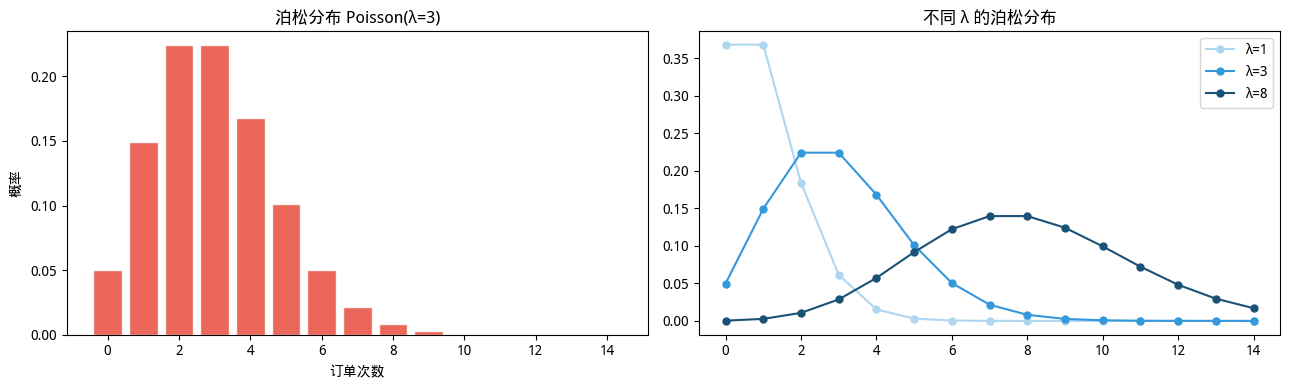

某分钟没有订单的概率：0.0498 (4.98%)
某分钟超过5次订单的概率：0.0839 (8.39%)


In [2]:
# 某分钟平均 3 次订单
lam = 3
x = np.arange(0, 15)
pmf_poisson = stats.poisson.pmf(x, lam)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(x, pmf_poisson, color='#E74C3C', edgecolor='white', alpha=0.85)
axes[0].set_title(f'泊松分布 Poisson(λ={lam})', fontweight='bold')
axes[0].set_xlabel('订单次数')
axes[0].set_ylabel('概率')

# 不同 λ 的比较
for lam_i, color in [(1, '#AED6F1'), (3, '#3498DB'), (8, '#1A5276')]:
    axes[1].plot(x, stats.poisson.pmf(x, lam_i), marker='o', markersize=5,
                  label=f'λ={lam_i}', color=color)
axes[1].set_title('不同 λ 的泊松分布', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# 实际应用：某分钟没有订单的概率
p_zero = stats.poisson.pmf(0, lam)
print(f"某分钟没有订单的概率：{p_zero:.4f} ({p_zero*100:.2f}%)")
p_over5 = 1 - stats.poisson.cdf(5, lam)
print(f"某分钟超过5次订单的概率：{p_over5:.4f} ({p_over5*100:.2f}%)")


---

## 四、正态分布（深入）

正态分布在上一篇已经介绍过，这里补充几个实用操作：


In [3]:
# 标准化：Z = (X - μ) / σ
mu, sigma = 170, 8   # 身高
heights = np.random.normal(mu, sigma, 1000)

# 问题1：身高超过 185cm 的概率？
p_over185 = 1 - stats.norm.cdf(185, loc=mu, scale=sigma)
print(f"身高 > 185cm 的概率：{p_over185:.4f} ({p_over185*100:.2f}%)")

# 问题2：身高在 165~175cm 的概率？
p_range = stats.norm.cdf(175, mu, sigma) - stats.norm.cdf(165, mu, sigma)
print(f"165 ≤ 身高 ≤ 175cm 的概率：{p_range:.4f} ({p_range*100:.2f}%)")

# 问题3：前 10% 的高个子门槛是多少？
threshold = stats.norm.ppf(0.90, loc=mu, scale=sigma)
print(f"前 10% 的高个子门槛：{threshold:.1f}cm")

# 标准正态 Z 分数
z_scores = (heights - mu) / sigma
print(f"\n前5个Z分数：{z_scores[:5].round(2)}")
print("Z > 2 的比例（应约 2.5%）：", (z_scores > 2).mean().round(4))


身高 > 185cm 的概率：0.0304 (3.04%)
165 ≤ 身高 ≤ 175cm 的概率：0.4680 (46.80%)
前 10% 的高个子门槛：180.3cm

前5个Z分数：[ 0.2   0.94 -0.14 -0.52 -1.9 ]
Z > 2 的比例（应约 2.5%）： 0.023


---

## 五、指数分布（Exponential Distribution）

**适用场景**：等待事件发生的**时间**服从指数分布（无记忆性）。

**现实例子**：
- 等待下一次客服求助的时间
- 机器故障的时间间隔
- 用户等待外卖的时长


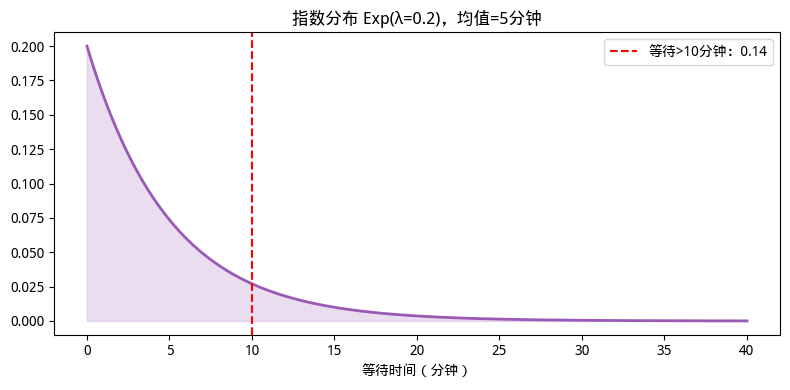

等待超过10分钟的概率：0.1353


In [4]:
lam_rate = 0.2   # 平均每 5 分钟发生一次（λ=1/5）

x = np.linspace(0, 40, 200)
pdf = stats.expon.pdf(x, scale=1/lam_rate)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, pdf, color='#9B59B6', linewidth=2)
ax.fill_between(x, pdf, alpha=0.2, color='#9B59B6')

# 等待时间超过 10 分钟的概率
p_over10 = 1 - stats.expon.cdf(10, scale=1/lam_rate)
ax.axvline(x=10, color='red', linestyle='--', linewidth=1.5, label=f'等待>10分钟：{p_over10:.2f}')
ax.set_title(f'指数分布 Exp(λ={lam_rate})，均值=5分钟', fontweight='bold')
ax.legend()
ax.set_xlabel('等待时间（分钟）')
plt.tight_layout()
plt.show()
print(f"等待超过10分钟的概率：{p_over10:.4f}")


---

## 六、常见分布对比速查

| 分布 | 类型 | 参数 | 均值 | 适用场景 |
|------|------|------|------|---------|
| 二项 B(n,p) | 离散 | n次试验，成功率p | np | 点击/转化次数 |
| 泊松 Poisson(λ) | 离散 | 平均发生次数λ | λ | 单位时间内事件次数 |
| 正态 N(μ,σ²) | 连续 | 均值μ，方差σ² | μ | 身高/测量误差 |
| 指数 Exp(λ) | 连续 | 事件发生率λ | 1/λ | 等待时间 |
| 均匀 U(a,b) | 连续/离散 | 最小值a，最大值b | (a+b)/2 | 随机选择 |

---

## 七、🔧 综合实战：业务场景中的概率计算

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


In [5]:
import numpy as np
from scipy import stats

# ── 场景1：推送召回率估算 ──
# 某 App 推送，历史打开率 8%，今天给 10000 人推送
# 问：至少有 900 人打开的概率？
n_push, p_open = 10000, 0.08
# 二项分布（n很大时用正态近似）
mu_open = n_push * p_open
sigma_open = np.sqrt(n_push * p_open * (1 - p_open))
prob_900 = 1 - stats.norm.cdf(900, mu_open, sigma_open)
print(f"场景1 - 至少900人打开的概率：{prob_900:.4f}")

# ── 场景2：客服排队分析 ──
# 每分钟平均 4 个请求（泊松分布），客服能处理 6 个
# 问：某分钟请求超出处理能力（>6）的概率？
lam_cs = 4
prob_overload = 1 - stats.poisson.cdf(6, lam_cs)
print(f"场景2 - 某分钟客服过载的概率：{prob_overload:.4f}")

# ── 场景3：质检抽样 ──
# 工厂日产1000件，不合格率2%
# 随机抽50件，超过2件不合格的概率？
n_sample, p_defect = 50, 0.02
prob_defect = 1 - stats.binom.cdf(2, n_sample, p_defect)
print(f"场景3 - 抽样超2件不合格的概率：{prob_defect:.4f}")

# ── 场景4：用户等待容忍度 ──
# 页面加载时间服从指数分布，均值2秒
# 用户等待超过5秒就会离开，流失率？
lam_load = 1/2   # 均值2秒
churn_rate = 1 - stats.expon.cdf(5, scale=1/lam_load)
print(f"场景4 - 加载超5秒的流失率：{churn_rate:.4f} ({churn_rate*100:.1f}%)")


场景1 - 至少900人打开的概率：0.0001
场景2 - 某分钟客服过载的概率：0.1107
场景3 - 抽样超2件不合格的概率：0.0784
场景4 - 加载超5秒的流失率：0.0821 (8.2%)


---

## 八、📝 小结

| 记忆要点 | 内容 |
|---------|------|
| 二项分布 | n 次试验的成功次数，B(n,p) |
| 泊松分布 | 单位时间稀少事件次数，λ = 均值 |
| 正态分布 | 连续，±1/2/3σ 覆盖 68/95/99.7% |
| 指数分布 | 等待时间，均值 = 1/λ，无记忆性 |

---

## 九、🏋️ 课后练习

1. 某广告的点击率为 3%，发出 200 次展示，计算恰好有 5 次点击的概率（二项分布）。
2. 一台机器每小时平均出现 0.5 次故障，计算 2 小时内故障次数超过 2 次的概率（泊松）。
3. 你的 App 加载时间服从 N(1.5, 0.4²)，用户超过 3 秒就流失，计算流失率。

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 设置中文字体和主题
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# seaborn 主题会覆盖字体设置，重新指定中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [6]:
print("练习1: 二项分布 - 广告点击率问题")

# 参数设置
p_click = 0.03       # 点击率 3%
n_shows = 200       # 展示次数
k_exact = 5         # 恰好5次点击

# 计算恰好5次点击的概率
# P(X=k) = C(n,k) * p^k * (1-p)^(n-k)
prob_exact_5 = stats.binom.pmf(k_exact, n_shows, p_click)

print(f"题目: 广告点击率 = {p_click*100}%, 展示次数 = {n_shows}")
print(f"计算: 恰好有 {k_exact} 次点击的概率")
print(f"结果: P(X={k_exact}) = {prob_exact_5:.6f} = {prob_exact_5*100:.4f}%")

# 补充：计算点击次数的期望和方差
expected_clicks = n_shows * p_click
variance_clicks = n_shows * p_click * (1 - p_click)
print(f"\n补充信息:")
print(f"  期望点击次数: E(X) = {expected_clicks:.2f}")
print(f"  点击次数方差: Var(X) = {variance_clicks:.2f}")
print(f"  点击次数标准差: SD(X) = {np.sqrt(variance_clicks):.2f}")

练习1: 二项分布 - 广告点击率问题
题目: 广告点击率 = 3.0%, 展示次数 = 200
计算: 恰好有 5 次点击的概率
结果: P(X=5) = 0.162250 = 16.2250%

补充信息:
  期望点击次数: E(X) = 6.00
  点击次数方差: Var(X) = 5.82
  点击次数标准差: SD(X) = 2.41


In [7]:
# 练习2: 泊松分布 - 机器故障问题
print("练习2: 泊松分布 - 机器故障问题")

# 参数设置
lambda_rate = 0.5     # 每小时平均0.5次故障
time_period = 2      # 2小时
lambda_2h = lambda_rate * time_period  # 2小时内平均故障次数

# 计算2小时内故障次数超过2次的概率
# P(X > 2) = 1 - P(X <= 2) = 1 - [P(X=0) + P(X=1) + P(X=2)]
prob_0 = stats.poisson.pmf(0, lambda_2h)
prob_1 = stats.poisson.pmf(1, lambda_2h)
prob_2 = stats.poisson.pmf(2, lambda_2h)
prob_at_most_2 = prob_0 + prob_1 + prob_2
prob_more_than_2 = 1 - prob_at_most_2

print(f"题目: 每小时平均故障次数 λ = {lambda_rate}")
print(f"      计算 {time_period} 小时内故障次数超过 2 次的概率")
print(f"\n计算过程:")
print(f"  2小时内平均故障次数 λ*t = {lambda_2h}")
print(f"  P(X=0) = {prob_0:.6f}")
print(f"  P(X=1) = {prob_1:.6f}")
print(f"  P(X=2) = {prob_2:.6f}")
print(f"  P(X <= 2) = {prob_at_most_2:.6f}")
print(f"\n结果: P(X > 2) = 1 - P(X <= 2) = {prob_more_than_2:.6f} = {prob_more_than_2*100:.4f}%")

# 也可以直接用泊松分布的生存函数
prob_gt_2_direct = 1 - stats.poisson.cdf(2, lambda_2h)
print(f"验证 (使用生存函数): P(X > 2) = {prob_gt_2_direct:.6f}")

练习2: 泊松分布 - 机器故障问题
题目: 每小时平均故障次数 λ = 0.5
      计算 2 小时内故障次数超过 2 次的概率

计算过程:
  2小时内平均故障次数 λ*t = 1.0
  P(X=0) = 0.367879
  P(X=1) = 0.367879
  P(X=2) = 0.183940
  P(X <= 2) = 0.919699

结果: P(X > 2) = 1 - P(X <= 2) = 0.080301 = 8.0301%
验证 (使用生存函数): P(X > 2) = 0.080301


In [10]:
print("练习3: 正态分布 - App加载时间流失率")

# 参数设置
mean_load = 1.5      # 平均加载时间（秒）
std_load = 0.4       # 标准差（秒）
threshold = 3.0      # 用户流失阈值（秒）

# 计算用户流失率 P(X > 3秒)
# 先计算Z值，然后查标准正态分布
z_score = (threshold - mean_load) / std_load
churn_rate = 1 - stats.norm.cdf(z_score)

print(f"题目: App加载时间 ~ N(μ={mean_load}, σ={std_load})")
print(f"      用户超过 {threshold} 秒就流失")
print(f"\n计算过程:")
print(f"  Z值 = (X - μ) / σ = ({threshold} - {mean_load}) / {std_load} = {z_score:.4f}")
print(f"  P(X > {threshold}) = P(Z > {z_score:.4f})")
print(f"\n结果: 用户流失率 = {churn_rate:.6f} = {churn_rate*100:.4f}%")

# 补充：加载时间分布信息
print(f"\n补充信息:")
print(f"  加载时间在2秒内的比例: P(X < 2) = {stats.norm.cdf(2, mean_load, std_load)*100:.2f}%")
print(f"  加载时间在1-2秒内的比例: P(1 < X < 2) = {(stats.norm.cdf(2, mean_load, std_load) - stats.norm.cdf(1, mean_load, std_load))*100:.2f}%")

练习3: 正态分布 - App加载时间流失率
题目: App加载时间 ~ N(μ=1.5, σ=0.4)
      用户超过 3.0 秒就流失

计算过程:
  Z值 = (X - μ) / σ = (3.0 - 1.5) / 0.4 = 3.7500
  P(X > 3.0) = P(Z > 3.7500)

结果: 用户流失率 = 0.000088 = 0.0088%

补充信息:
  加载时间在2秒内的比例: P(X < 2) = 89.44%
  加载时间在1-2秒内的比例: P(1 < X < 2) = 78.87%


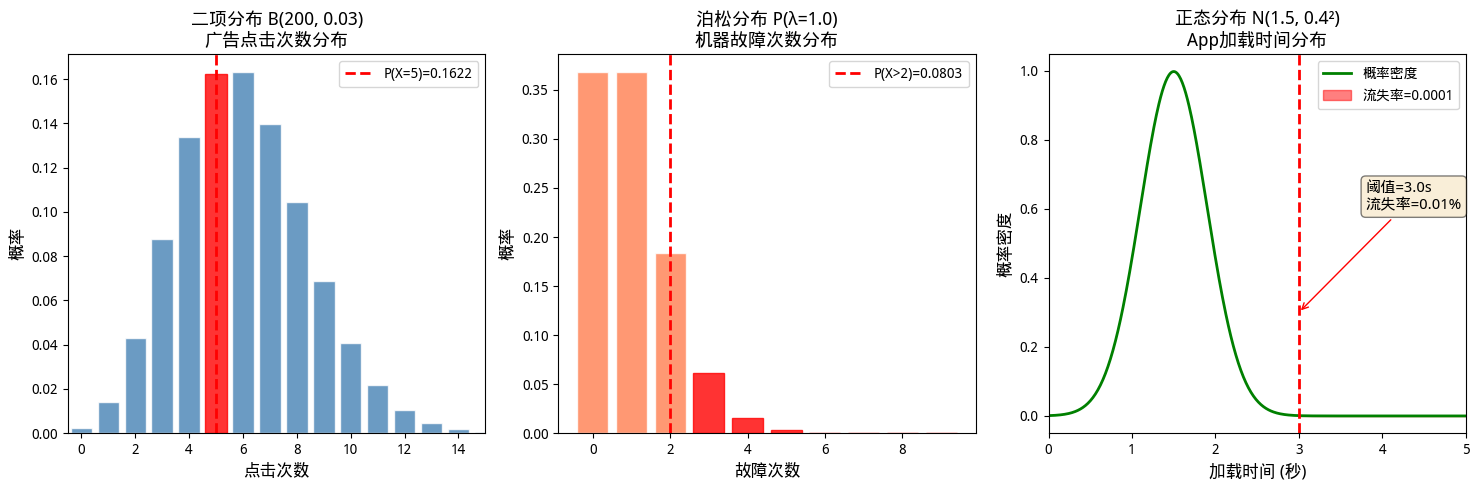

In [12]:
# 增加可视化图表，加强理解
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 图1: 二项分布 B(200, 0.03)
ax1 = axes[0]
k_range = np.arange(0, 20)
probs_binom = stats.binom.pmf(k_range, n_shows, p_click)
bars1 = ax1.bar(k_range, probs_binom, color='steelblue', edgecolor='white', alpha=0.8)
# 标注恰好5次的概率
bars1[5].set_color('red')
ax1.axvline(x=5, color='red', linestyle='--', linewidth=2, label=f'P(X=5)={prob_exact_5:.4f}')
ax1.set_xlabel('点击次数', fontsize=12)
ax1.set_ylabel('概率', fontsize=12)
ax1.set_title('二项分布 B(200, 0.03)\n广告点击次数分布', fontsize=13)
ax1.legend(loc='upper right')
ax1.set_xlim(-0.5, 15)

# 图2: 泊松分布 P(λ=1)
ax2 = axes[1]
k_range_poisson = np.arange(0, 10)
probs_poisson = stats.poisson.pmf(k_range_poisson, lambda_2h)
bars2 = ax2.bar(k_range_poisson, probs_poisson, color='coral', edgecolor='white', alpha=0.8)
# 标注 >2 的区域
for i in range(3, len(bars2)):
    bars2[i].set_color('red')
ax2.axvline(x=2, color='red', linestyle='--', linewidth=2, label=f'P(X>2)={prob_more_than_2:.4f}')
ax2.set_xlabel('故障次数', fontsize=12)
ax2.set_ylabel('概率', fontsize=12)
ax2.set_title(f'泊松分布 P(λ={lambda_2h})\n机器故障次数分布', fontsize=13)
ax2.legend(loc='upper right')

# 图3: 正态分布 N(1.5, 0.4²)
ax3 = axes[2]
x_range = np.linspace(0, 5, 500)
y_pdf = stats.norm.pdf(x_range, mean_load, std_load)
ax3.plot(x_range, y_pdf, 'g-', linewidth=2, label='概率密度')
ax3.fill_between(x_range, y_pdf, where=(x_range > threshold), color='red', alpha=0.5, label=f'流失率={churn_rate:.4f}')
ax3.axvline(x=threshold, color='red', linestyle='--', linewidth=2)
ax3.annotate(f'阈值={threshold}s\n流失率={churn_rate*100:.2f}%', 
             xy=(threshold, 0.3), xytext=(threshold+0.8, 0.6),
             fontsize=11, arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax3.set_xlabel('加载时间 (秒)', fontsize=12)
ax3.set_ylabel('概率密度', fontsize=12)
ax3.set_title(f'正态分布 N({mean_load}, {std_load}²)\nApp加载时间分布', fontsize=13)
ax3.legend(loc='upper right')
ax3.set_xlim(0, 5)

plt.tight_layout()
plt.show()


本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 33 篇：抽样与中心极限定理**
>
> 下篇来学统计推断的基石——中心极限定理。为什么样本均值总是趋向正态分布？这个定理是后续假设检验和置信区间的前提。

---

*跟着小荷，数据分析路上不迷路～*